# H5 — REC–LDI Pearson Coupling by Condition

**Test:** Pearson Correlation (per condition)  
**Question:** Are REC and LDI correlated, and does this differ by boundary type?  
**Hypothesis:** The REC–LDI relationship differs across conditions — some may show coupling, others a trade-off.

In [4]:
import warnings
import numpy as np
import pandas as pd
import pingouin as pg
from pathlib import Path
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-whitegrid")

In [5]:
def _header(title, width=75):
    print("\n" + "═" * width)
    print(f"  {title}")
    print("═" * width)

def _get_p(row):
    for c in row.index:
        if c in ("p-unc", "p-val", "p_val", "p_unc", "p"):
            return float(row[c])
    raise KeyError(f"No p-value column. Available: {list(row.index)}")

def _get_corr_p(cor_df):
    for c in cor_df.columns:
        if c in ("p-val", "p_val", "pval", "p"):
            return float(cor_df[c].values[0])
    raise KeyError(f"No corr p column. Available: {list(cor_df.columns)}")

def _sig(p):
    return "✅ Significant" if p < 0.05 else "❌ Not Significant"


In [8]:
CSV_PATH = Path('..')/ Path('..') / '01_Preprocessing' / 'compiled_preprocessed.csv'
df = pd.read_csv(CSV_PATH)

# Handle naming differences across preprocess versions.
col_candidates = {
    "participant": ["participant_uid", "participant_id", "Participant_ID"],
    "condition": ["condition", "Condition"],
    "trial_type": ["trial_type", "Trial_Type"],
    "response": ["user_response", "response", "User_Response"],
    "position": ["boundary_position", "Boundary_Position"],
    "rt": ["encoding_RT", "Encoding_RT", "encoding_rt", "Encoding_rt", "RT_encoding", "RT"],
}

resolved = {}
for key, candidates in col_candidates.items():
    resolved[key] = next((c for c in candidates if c in df.columns), None)

required_keys = ["participant", "condition", "trial_type", "response", "position"]
missing = [k for k in required_keys if resolved[k] is None]
if missing:
    raise ValueError(f"Missing required columns for {missing}. Found columns: {list(df.columns)}")

if resolved["rt"] is not None:
    df["Encoding_RT"] = pd.to_numeric(df[resolved["rt"]], errors="coerce")
else:
    df["Encoding_RT"] = np.nan
    print("Warning: No encoding RT column found; Encoding_RT set to NaN.")

pid_col = resolved["participant"]
cond_col = resolved["condition"]
trial_col = resolved["trial_type"]
resp_col = resolved["response"]
pos_col = resolved["position"]

# Normalize condition labels to prevent accidental duplicates from trailing spaces.
df[cond_col] = df[cond_col].astype(str).str.strip()

# ── Global rates (1 row per participant) ─────────────────────────────────────
g_records = []
for uid, g in df.groupby(pid_col):
    cond    = g[cond_col].iloc[0]
    foils   = g[g[trial_col] == "Foil"]
    targets = g[g[trial_col] == "Target"]
    lures   = g[g[trial_col] == "Lure"]
    fa_t = (foils[resp_col]   == "Target").mean() if len(foils)   > 0 else 0.0
    fa_l = (foils[resp_col]   == "Lure"  ).mean() if len(foils)   > 0 else 0.0
    hit  = (targets[resp_col] == "Target").mean() if len(targets) > 0 else 0.0
    sim  = (lures[resp_col]   == "Lure"  ).mean() if len(lures)   > 0 else 0.0
    g_records.append({
        "participant_uid": uid, "condition": cond,
        "FA_Target": fa_t, "FA_Lure": fa_l,
        "Hit_Rate": hit,   "Sim_Rate": sim,
        "REC": hit - fa_t, "LDI": sim - fa_l,
        "Encoding_RT": g["Encoding_RT"].mean(),
    })
global_df = pd.DataFrame(g_records)
global_df.dropna(subset=["REC", "LDI"], inplace=True)

# ── Position-specific rates ───────────────────────────────────────────────────
p_records = []
pos_trials = df[df[pos_col].isin(["Pre", "Mid", "Post"])]
for (uid, pos), g in pos_trials.groupby([pid_col, pos_col]):
    cond    = g[cond_col].iloc[0]
    targets = g[g[trial_col] == "Target"]
    lures   = g[g[trial_col] == "Lure"]
    pos_hit = (targets[resp_col] == "Target").mean() if len(targets) > 0 else 0.0
    pos_sim = (lures[resp_col]   == "Lure"  ).mean() if len(lures)   > 0 else 0.0
    fa_row  = global_df[global_df["participant_uid"] == uid]
    fa_t    = float(fa_row["FA_Target"].values[0]) if len(fa_row) > 0 else 0.0
    fa_l    = float(fa_row["FA_Lure"  ].values[0]) if len(fa_row) > 0 else 0.0
    p_records.append({
        "participant_uid": uid, "condition": cond,
        "boundary_position": pos,
        "REC": pos_hit - fa_t, "LDI": pos_sim - fa_l,
        "Encoding_RT": g["Encoding_RT"].mean(),
    })
position_df = pd.DataFrame(p_records)
counts = position_df.groupby("participant_uid")["boundary_position"].nunique()
valid  = counts[counts == 3].index
position_df = position_df[position_df["participant_uid"].isin(valid)].copy()
position_df.dropna(subset=["REC", "LDI"], inplace=True)

print(f"Global subjects                              : {len(global_df)}")
print(f"Position subjects (balanced, 3 positions)    : {position_df['participant_uid'].nunique()}")


Global subjects                              : 160
Position subjects (balanced, 3 positions)    : 160


In [9]:
_header("H5: REC–LDI Pearson Correlation by Condition")
print("  r > 0  → recognition & discrimination move together (coupled)")
print("  r < 0  → trade-off between the two processes\n")

for cond in sorted(global_df["condition"].unique()):
    sub = global_df[global_df["condition"] == cond][["REC", "LDI"]].dropna()
    if len(sub) < 3:
        print(f"  {cond:<22} | n={len(sub)} — skipping"); continue
    cor   = pg.corr(sub["REC"], sub["LDI"], method="pearson")
    r     = cor["r"].values[0]
    p_val = _get_corr_p(cor)
    print(f"  {cond:<22} | n={len(sub):>3}  |  r = {r:+.3f}   p = {p_val:.4f}   {_sig(p_val)}")



═══════════════════════════════════════════════════════════════════════════
  H5: REC–LDI Pearson Correlation by Condition
═══════════════════════════════════════════════════════════════════════════
  r > 0  → recognition & discrimination move together (coupled)
  r < 0  → trade-off between the two processes

  Both_item_task         | n= 51  |  r = -0.120   p = 0.4003   ❌ Not Significant
  item_only              | n= 56  |  r = +0.153   p = 0.2613   ❌ Not Significant
  task_only              | n= 53  |  r = +0.392   p = 0.0037   ✅ Significant


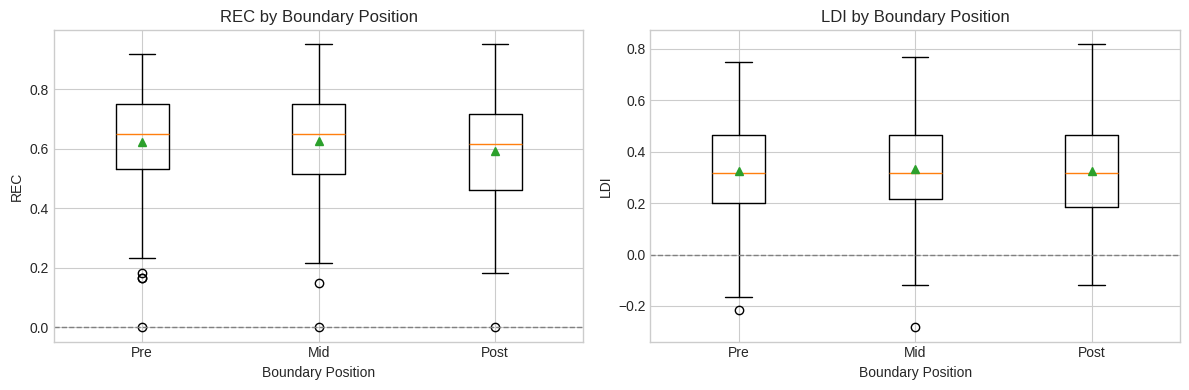

In [10]:
# Boundary-position distributions for REC and LDI
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for idx, metric in enumerate(["REC", "LDI"]):
    ax = axes[idx]
    order = ["Pre", "Mid", "Post"]
    data = [
        position_df[position_df["boundary_position"] == p][metric].dropna().values
        for p in order
    ]
    ax.boxplot(data, labels=order, showmeans=True)
    ax.axhline(0, color="gray", linewidth=1, linestyle="--")
    ax.set_title(f"{metric} by Boundary Position")
    ax.set_xlabel("Boundary Position")
    ax.set_ylabel(metric)

plt.tight_layout()
plt.show()

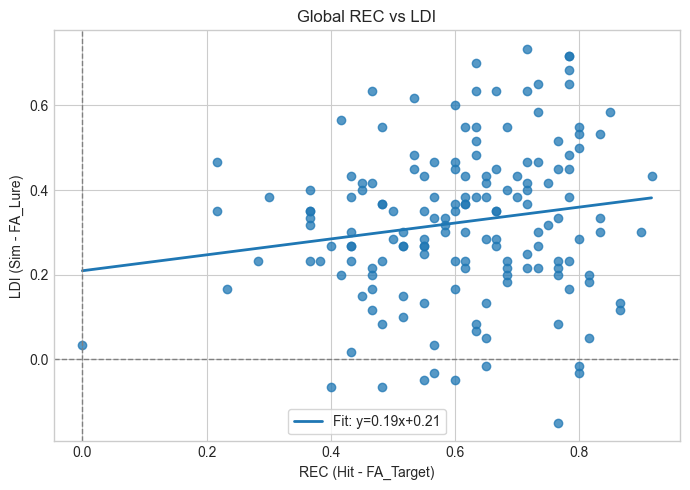

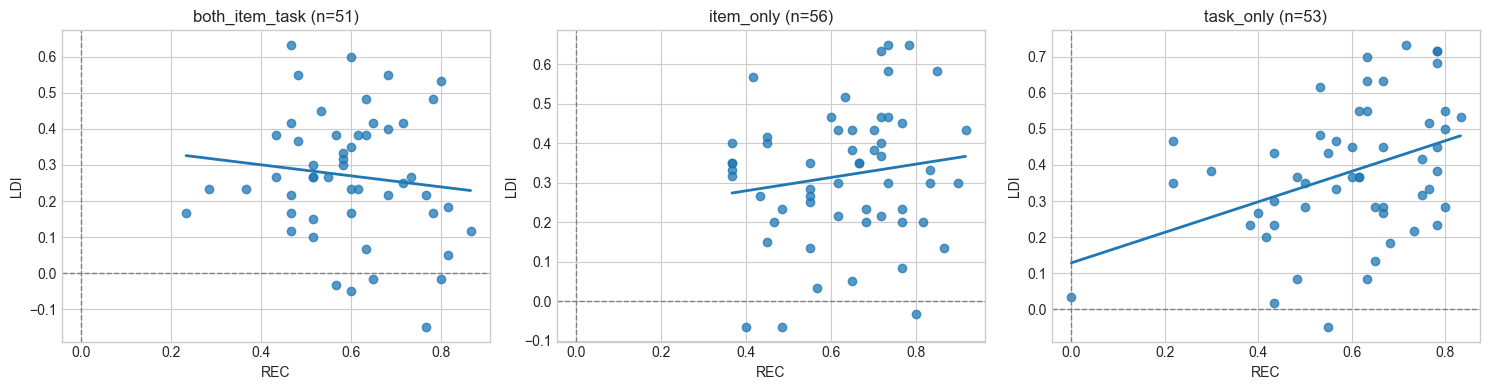

In [13]:
# Global REC-LDI scatter with best-fit line
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(global_df["REC"], global_df["LDI"], alpha=0.75)

if len(global_df) >= 2:
    m, b = np.polyfit(global_df["REC"], global_df["LDI"], 1)
    xs = np.linspace(global_df["REC"].min(), global_df["REC"].max(), 100)
    ax.plot(xs, m * xs + b, linewidth=2, label=f"Fit: y={m:.2f}x+{b:.2f}")
    ax.legend(frameon=True)

ax.axhline(0, color="gray", linewidth=1, linestyle="--")
ax.axvline(0, color="gray", linewidth=1, linestyle="--")
ax.set_title("Global REC vs LDI")
ax.set_xlabel("REC (Hit - FA_Target)")
ax.set_ylabel("LDI (Sim - FA_Lure)")
plt.tight_layout()
plt.show()

# Condition-wise REC-LDI scatter
conds = sorted(global_df["condition"].dropna().unique())
n = len(conds)
cols = min(3, max(1, n))
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows), squeeze=False)
for i, cond in enumerate(conds):
    r, c = divmod(i, cols)
    ax = axes[r][c]
    sub = global_df[global_df["condition"] == cond]
    ax.scatter(sub["REC"], sub["LDI"], alpha=0.75)

    if len(sub) >= 2 and sub["REC"].nunique() > 1:
        m, b = np.polyfit(sub["REC"], sub["LDI"], 1)
        xs = np.linspace(sub["REC"].min(), sub["REC"].max(), 100)
        ax.plot(xs, m * xs + b, linewidth=2)

    ax.axhline(0, color="gray", linewidth=1, linestyle="--")
    ax.axvline(0, color="gray", linewidth=1, linestyle="--")
    ax.set_title(f"{cond} (n={len(sub)})")
    ax.set_xlabel("REC")
    ax.set_ylabel("LDI")

# Hide any unused subplot axes
for j in range(n, rows * cols):
    r, c = divmod(j, cols)
    axes[r][c].axis("off")

plt.tight_layout()
plt.show()

## Visualization

Scatter plots below show REC vs LDI globally, by condition, and by boundary position.